In [2234]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3

In [2235]:
conn = sqlite3.connect('../../../databases/stm8l_profiling.py_20250920_024157.sqlite')

In [2236]:
df = pd.read_sql("SELECT * FROM experiments", conn)

df['voltage'] = df['voltage'] / 100
df['response'] = df['response'].astype(str)

df.head()

,id,voltage,delay,length,color,response
0,1520,0.9,1889,24,R,success
1,1551,0.9,1890,24,R,success
2,1700,0.9,1888,24,R,success
3,1766,0.9,1889,24,R,success
4,1769,0.9,1888,24,R,success


In [2237]:
df.groupby(['voltage', 'length']).size().sort_values(ascending=False).head(10)

voltage  length
1.22     28        27
1.24     28        27
1.19     24        22
0.97     24        20
1.06     24        20
1.12     24        18
1.19     28        18
1.10     24        18
0.96     24        18
1.21     28        18
dtype: int64

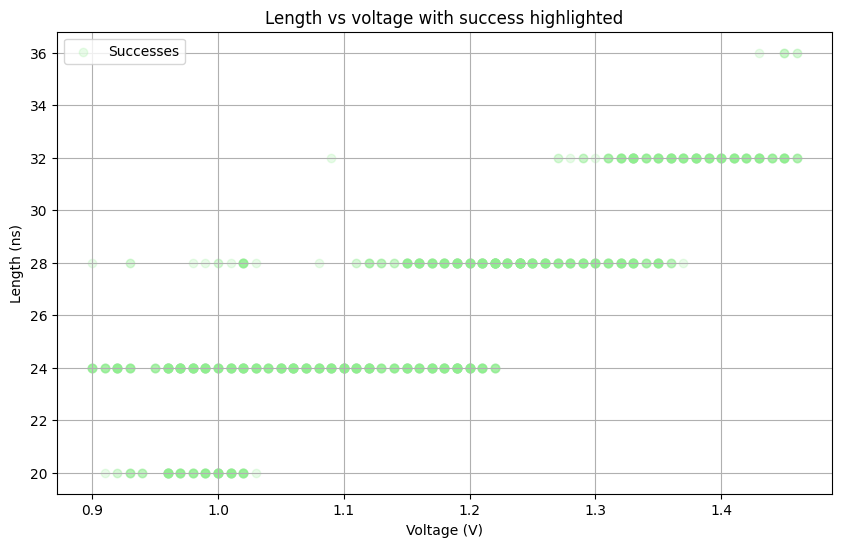

In [2238]:
plt.figure(figsize=(10, 6))
plt.scatter(df[df['response'] == 'success']['voltage'], df[df['response'] == 'success']['length'], c='lightgreen', label='Successes', alpha=0.2)
plt.xlabel('Voltage (V)')
plt.ylabel('Length (ns)')
plt.title('Length vs voltage with success highlighted')
plt.legend()
plt.grid(True)
plt.show()


In [2239]:
# SELECT 
#     response,
#     COUNT(*) AS group_count,
#     ROUND( COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2 ) AS percentage
# FROM experiments
# GROUP BY response;;